# Imports

In [3]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from PIL import Image
from scipy.signal import convolve2d
import cv2

# Methods

In [ ]:
def find_contorno(imagem):
    """Verifica se a imagem contém a letra A maiúscula"""
    # Binariza a imagem (inversão: fundo branco, letras pretas)
    _, img_bin = cv2.threshold(imagem, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Encontra contornos (possíveis letras)
    contornos, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return contornos, img_bin

def tm_ccoef_normed(image: np.ndarray, template: np.ndarray) -> np.ndarray:
    """
    Calcula a correlação cruzada normalizada (TM_CCOEFF_NORMED) entre a imagem e o template.

    Parâmetros:
    - image: imagem de entrada (2D, em escala de cinza)
    - template: template a ser comparado (2D, em escala de cinza)

    Retorna:
    - result: mapa de similaridade (valores entre -1 e 1)
    """
    img_h, img_w = image.shape
    tpl_h, tpl_w = template.shape

    # Média e T' do template
    template_mean = np.mean(template)
    template_prime = template - template_mean
    template_prime_squared_sum = np.sum(template_prime ** 2)

    # Saída terá tamanho reduzido
    result_h = img_h - tpl_h + 1
    result_w = img_w - tpl_w + 1
    result = np.zeros((result_h, result_w), dtype=np.float32)

    # Para cada posição possível (x, y) na imagem:
    for y in range(result_h):
        for x in range(result_w):
            region = image[y:(y + tpl_h), x:(x + tpl_w)]
            region_mean = np.mean(region)
            region_prime = region - region_mean
            region_prime_squared_sum = np.sum(region_prime ** 2)

            numerator = np.sum(template_prime * region_prime)
            denominator = np.sqrt(template_prime_squared_sum * region_prime_squared_sum)

            result[y, x] = numerator / denominator if denominator != 0 else 0.0

    return result


# Parameters

In [8]:
path_assets = PROJECT_DIR / 'assets'

# Questão 08

## 1) 1º imagem

### 1.1) Lendo letra "A" de template para comparação

In [9]:
# Leitura de imagens
file_path_template_A = str(path_assets / "atv02-q08-01_template_A.png")
image_path = str(path_assets / "atv02_lista02-assets" / "Book_1.png")

image_book = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
image_template = cv2.imread(file_path_template_A, cv2.IMREAD_GRAYSCALE)

# parametros para salvar
contents = {
    "contornos": [],
    "letra": [],
    "letra_norm": [],
    "similarity": [],
    "check_is_valid": []
}

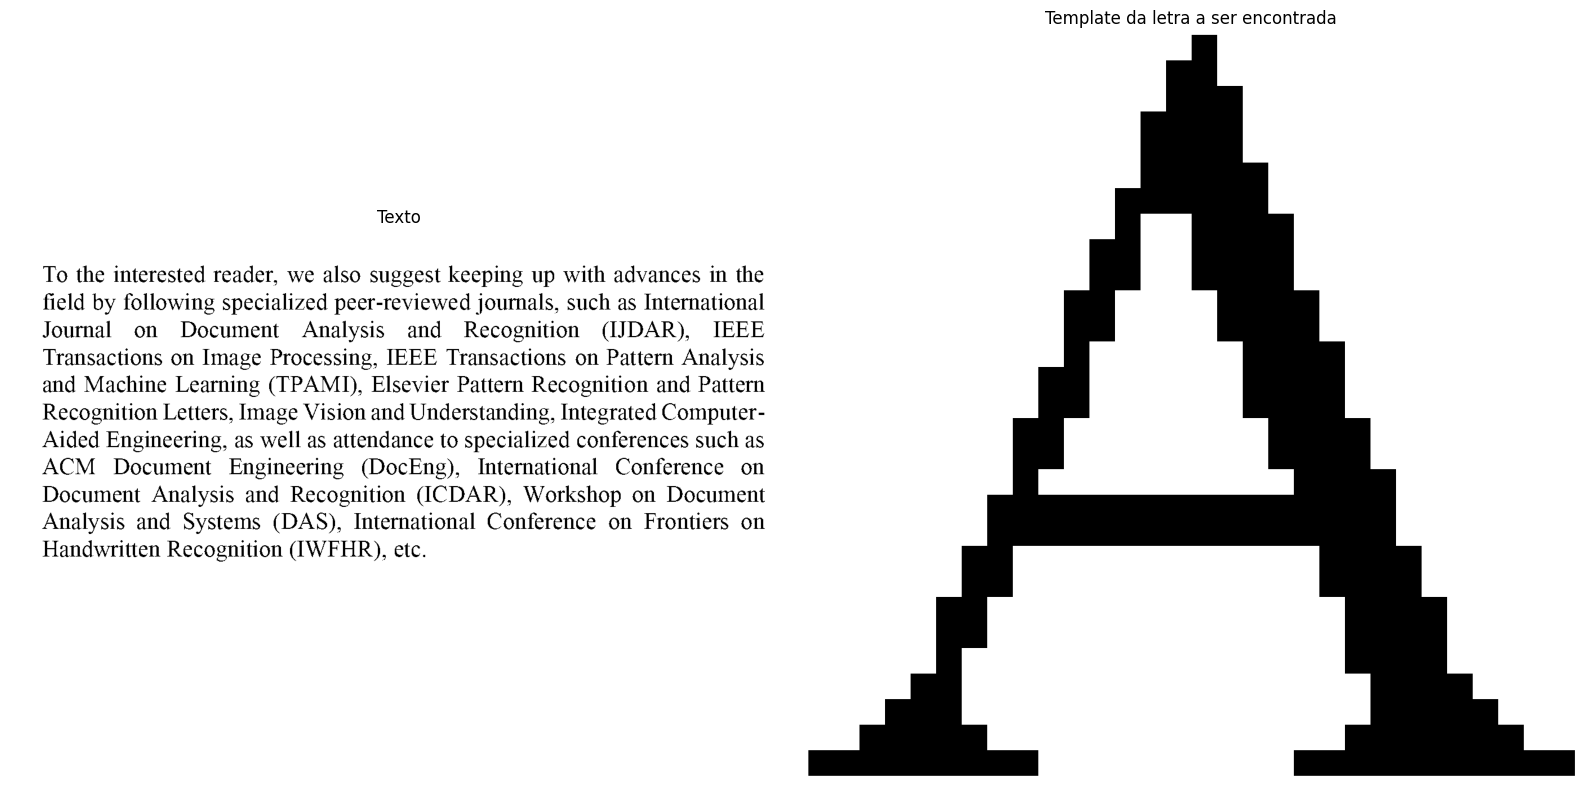

In [10]:
# Plot para o texto versus a letra a ser encontrada
fig_q8_i, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(image_book, cmap='gray')
ax[1].imshow(image_template, cmap='gray')
ax[0].axis('off')
ax[1].axis('off')
ax[0].set_title("Texto")
ax[1].set_title("Template da letra a ser encontrada")
fig_q8_i.tight_layout()
fig_q8_i.savefig(path_assets / "atv02-q08-i01_k02.png", dpi=400, bbox_inches='tight')
plt.show()

### 1.2) Geração de contornos

Nesse trecho, primeiro sera feito a inversão da cor da imagem, fundo branco com letra preta, será invertido para fundo preto com letra branca, para facilitar a detecção dos contornos.

In [11]:
# Pega os contornos e a imagem binarizada
contornos, img_bin = find_contorno(image_book)

# Faz uma cópia colorida da imagem original (para desenhar colorido)
imagem_com_contornos = cv2.cvtColor(image_book, cv2.COLOR_GRAY2BGR)

# Desenha os contornos
_ = cv2.drawContours(imagem_com_contornos, contornos, -1, (0, 255, 0), 1)

### 1.3) Ilustração do processo de binarização e contornos

Abaixo temos a imagem binarizada, apos a inversão e ao lado o contorno de cada letra encontrada.

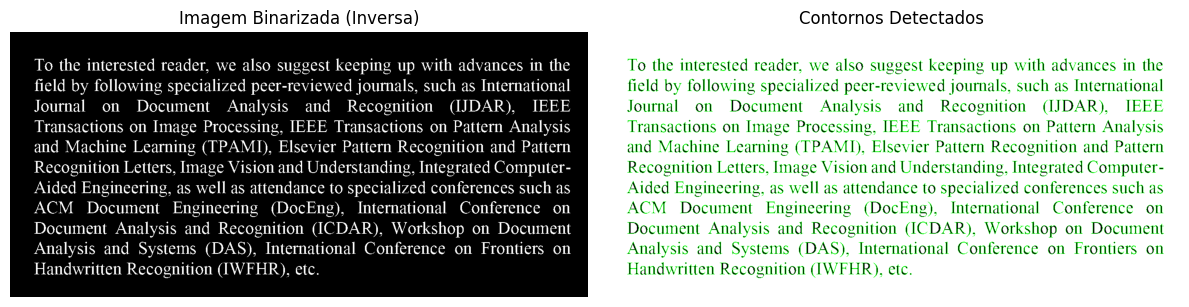

In [12]:
# Mostra imagem binarizada e com contornos lado a lado
fig1, ax1 = plt.subplots(1, 2, figsize=(12, 5))
ax1[0].set_title("Imagem Binarizada (Inversa)")
ax1[0].imshow(img_bin, cmap='gray')
ax1[0].axis('off')

ax1[1].set_title("Contornos Detectados")
ax1[1].imshow(imagem_com_contornos, cmap='gray')
ax1[1].axis('off')

fig1.tight_layout()
fig1.savefig(path_assets / "atv02-q08-i01_k03.png", dpi=400, bbox_inches='tight')
plt.show()

### 1.4) Busca de similaridade com o template utilizado

Abaixo, será aplicado a cada contorno encontrado um calculo de similaridade (`TM_CCOEFF_NORMED`), com a implementação disponibilizada pela [*OpenCV*](https://docs.opencv.org/4.x/df/dfb/group__imgproc__object.html). A formula para essa similidade pode ser expressa pela equação abaixo:

$$
R(x, y) = \frac{\sum_{x^{'}, y^{'}} (T^{'}(x^{'}, y^{'}) \cdot I^{'}(x + x^{'}, y + y^{'}))}{\sqrt{\sum_{x^{'}, y^{'}} T^{'}(x^{'}, y^{'})^{2} \cdot \sum_{x^{'}, y^{'}} I^{'}(x + x^{'}, y + y^{'})^{2}}}
$$

Abaixo, será  calculado e armazenado as similidades, por meio de uma função criada, além de visualizar uma pequena amostra de letras e suas respectivas similaridades.

Text(0.5, 0.98, 'Amostra de letras e similaridade calculada')

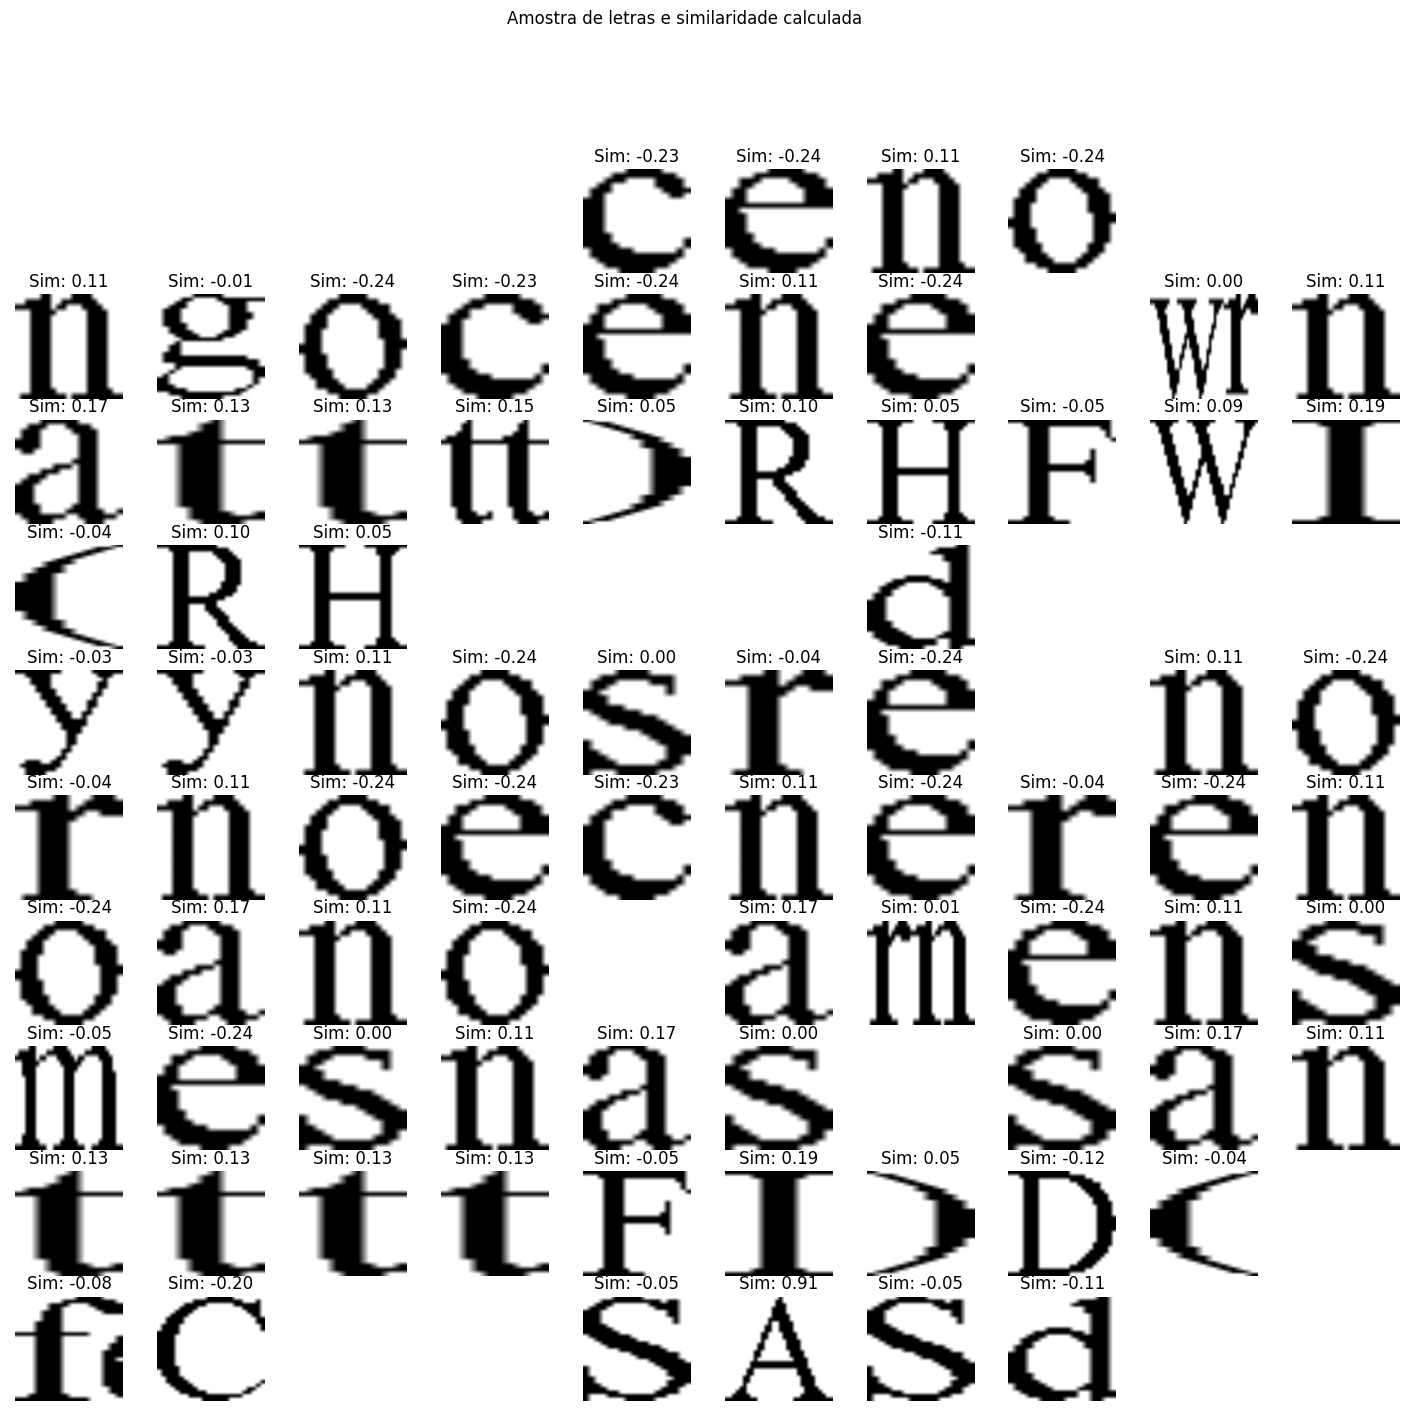

In [ ]:
fig, ax = plt.subplots(10, 10, figsize=(18, 16))
ax = ax.flatten()
for i, contorno in enumerate(contornos):
    x, y, w, h = cv2.boundingRect(contorno)

    letra = img_bin[y:(y + h), x:(x + w)]  # recorta a letra da iamgem
    letra_resized = cv2.resize(
        letra,
        (image_template.shape[1], image_template.shape[0])
    )  # redimensiona para o tamanho do template

    letra_norm = 1 - letra_resized / 255.0 # re normalizando para retornar com o fundo branco e letra preta

    # Outro formato de uso usando a biblioteca OpenCV ###############################################################
    # res = cv2.matchTemplate(
    #     letra_norm.astype(np.float32),
    #     image_template.astype(np.float32),
    #     cv2.TM_CCOEFF_NORMED
    # )[0][0]  # calculo de similaridade explicitado
    #################################################################################################################
    res = tm_ccoef_normed(letra_norm, image_template)  # calculo de similaridade
    # simililarity = res[0][0]
    simililarity = res[0][0]

    contents["contornos"].append(contorno)
    contents["letra"].append(letra)
    contents["letra_norm"].append(letra_norm)
    contents["similarity"].append(simililarity)

    if w < 10 or h < 10:  # contornos muito pequenos não serão mostrados
        if i < (10 * 10):
            ax[i].axis("off")
        contents["check_is_valid"].append(False)
        continue
    contents["check_is_valid"].append(True)

    if i < (10 * 10):
        ax[i].imshow(letra_norm, cmap='gray')
        ax[i].axis("off")
        ax[i].set_title(f"Sim: {simililarity:.2f}")
fig.savefig(path_assets / "atv02-q08-i01_k04.png", dpi=400, bbox_inches='tight')
fig.suptitle("Amostra de letras e similaridade calculada")

### 1.5) Threshold para similaridade

Considerando o  calculo utilizado para a similaridade, será utilizado um *threshold* de $0.5$ para a métrica utilizada, aonde temos:

$$
\text{Resultado} = 
\begin{cases} 
\text{Letra 'A' encontrada}, & \text{se } thres \geq 0.5 \\
\text{Letra 'A' não encontrada}, & \text{se } thres < 0.5
\end{cases}
$$

### 1.6) Conclusão

O algoritmo desenvolvido conseguiu detectar a presença da letra **A** maiuscula ao longo da imagem.

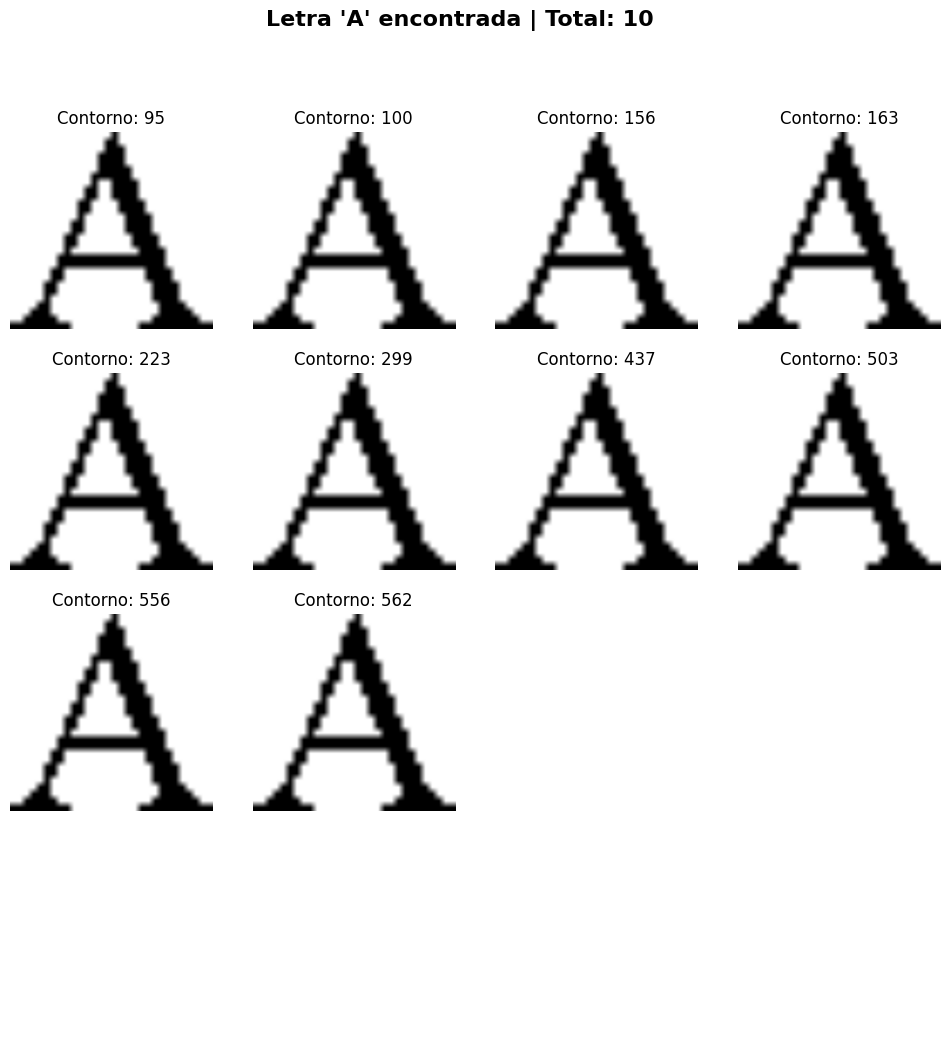

In [151]:
p = 0.5
ks = np.where((np.array(contents["similarity"]) >= p) & (np.array(contents["check_is_valid"]) == True))[0]
n = math.ceil(math.sqrt(len(ks)))

if n != 0:
    fig, axes = plt.subplots(
        n,
        n,
        figsize=(n * 3, n * 3)
    )


    for value, _axes in zip(ks, axes.flatten()):
        _axes.imshow(contents["letra_norm"][value], cmap="gray")
        _axes.set_title(f"Contorno: {value}")

    for _axes in axes.flatten():
        _axes.axis('off')

    text = f"Letra 'A' {'encontrada' if len(ks) >= 1 else 'inexistente'}"
    text += f" | Total: {len(ks)}"
    fig.suptitle(text, fontsize=16, weight='bold')
    fig.savefig(path_assets / "atv02-q08-i01_k05.png", dpi=400, bbox_inches='tight')
    plt.show()
else:
    fig, axes = plt.subplots(
        1,
        1,
        figsize=(16, 8)
    )
    axes.set_title("Letra 'A' não encontrada")
    axes.axis('off')
    fig.savefig(path_assets / "atv02-q08-i01_k05.png", dpi=400, bbox_inches='tight')

### 1.7) Extra

Devido ao formato da implementação, tornou-se facil detectar o número de letras **A** encontradas na iamgem, totalizando **10** encontradas pelo algoritmo.

## 2) 2º imagem

### 2.1) Lendo letra "A" de template para comparação

In [152]:
# Leitura de imagens
file_path_template_A = str(path_assets / "atv02-q08-01_template_A.png")
image_path = str(path_assets / "atv02_lista02-assets" / "Book_2.png")

image_book = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
image_template = cv2.imread(file_path_template_A, cv2.IMREAD_GRAYSCALE)

# parametros para salvar
contents = {
    "contornos": [],
    "letra": [],
    "letra_norm": [],
    "similarity": [],
    "check_is_valid": []
}

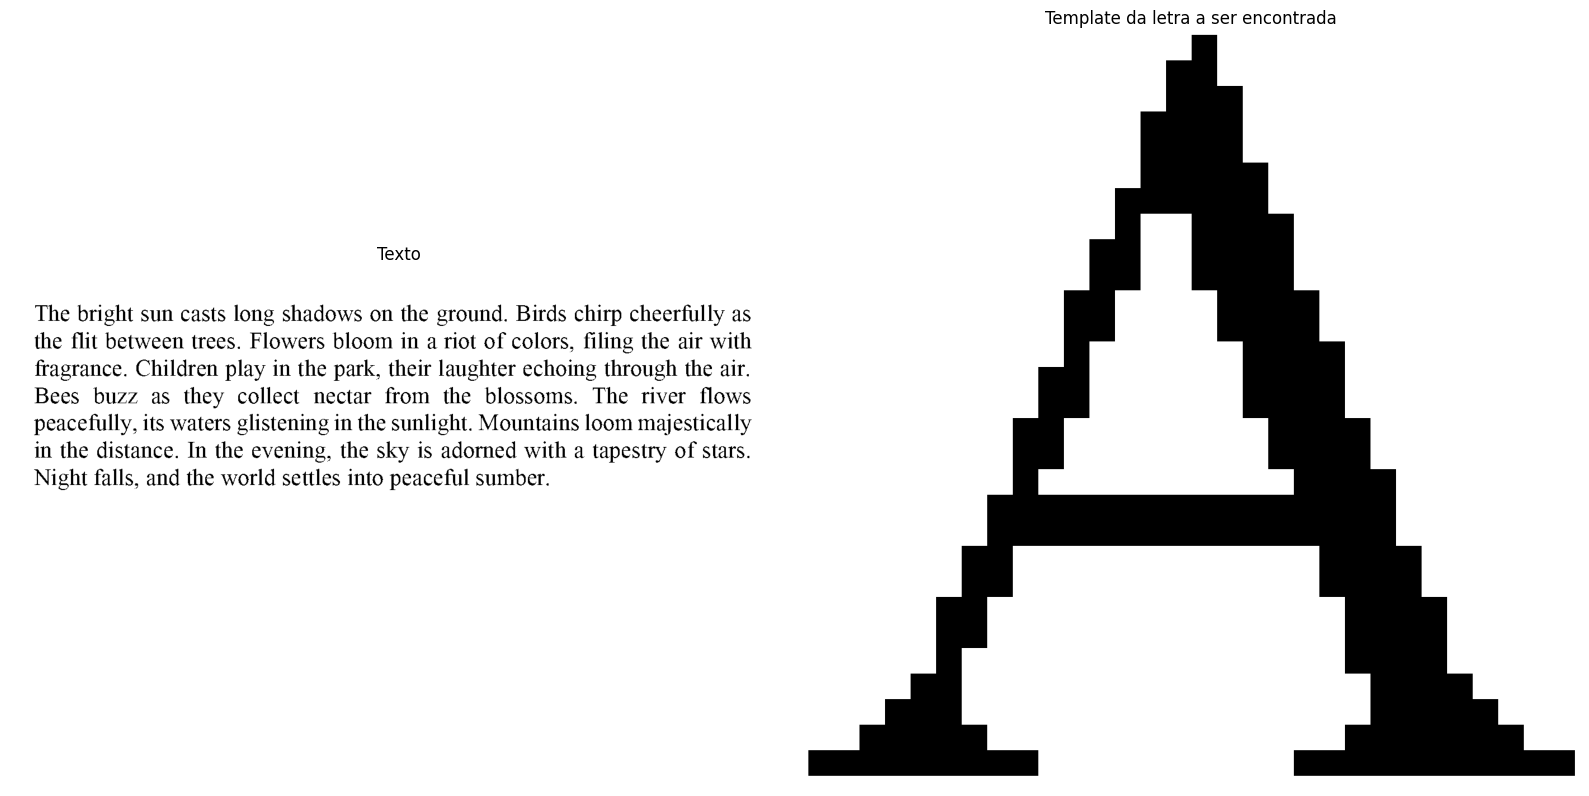

In [153]:
# Plot para o texto versus a letra a ser encontrada
fig_q8_i, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(image_book, cmap='gray')
ax[1].imshow(image_template, cmap='gray')
ax[0].axis('off')
ax[1].axis('off')
ax[0].set_title("Texto")
ax[1].set_title("Template da letra a ser encontrada")
fig_q8_i.tight_layout()
fig_q8_i.savefig(path_assets / "atv02-q08-i02_k02.png", dpi=400, bbox_inches='tight')
plt.show()

### 2.2) Geração de contornos

Nesse trecho, primeiro sera feito a inversão da cor da imagem, fundo branco com letra preta, será invertido para fundo preto com letra branca, para facilitar a detecção dos contornos.

In [154]:
# Pega os contornos e a imagem binarizada
contornos, img_bin = find_contorno(image_book)

# Faz uma cópia colorida da imagem original (para desenhar colorido)
imagem_com_contornos = cv2.cvtColor(image_book, cv2.COLOR_GRAY2BGR)

# Desenha os contornos
_ = cv2.drawContours(imagem_com_contornos, contornos, -1, (0, 255, 0), 1)

### 2.3) Ilustração do processo de binarização e contornos

Abaixo temos a imagem binarizada, apos a inversão e ao lado o contorno de cada letra encontrada.

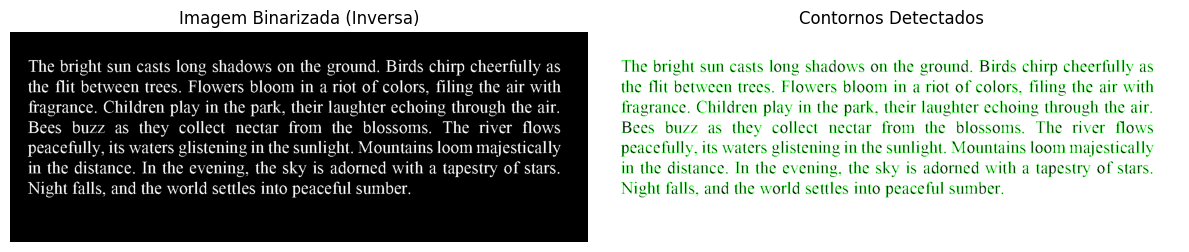

In [155]:
# Mostra imagem binarizada e com contornos lado a lado
fig1, ax1 = plt.subplots(1, 2, figsize=(12, 5))
ax1[0].set_title("Imagem Binarizada (Inversa)")
ax1[0].imshow(img_bin, cmap='gray')
ax1[0].axis('off')

ax1[1].set_title("Contornos Detectados")
ax1[1].imshow(imagem_com_contornos, cmap='gray')
ax1[1].axis('off')

fig1.tight_layout()
fig1.savefig(path_assets / "atv02-q08-i02_k03.png", dpi=400, bbox_inches='tight')
plt.show()

### 2.4) Busca de similaridade com o template utilizado

Abaixo, será aplicado a cada contorno encontrado um calculo de similaridade (`TM_CCOEFF_NORMED`), com a implementação disponibilizada pela [*OpenCV*](https://docs.opencv.org/4.x/df/dfb/group__imgproc__object.html). A formula para essa similidade pode ser expressa pela equação abaixo:

$$
R(x, y) = \frac{\sum_{x^{'}, y^{'}} (T^{'}(x^{'}, y^{'}) \cdot I^{'}(x + x^{'}, y + y^{'}))}{\sqrt{\sum_{x^{'}, y^{'}} T^{'}(x^{'}, y^{'})^{2} \cdot \sum_{x^{'}, y^{'}} I^{'}(x + x^{'}, y + y^{'})^{2}}}
$$

Sendo:

* $x, y$: coordenadas relativas do ponto na imagem;

* $x^{'}, y^{'}$: coordenadas relativas do ponto no template;

* $T^{'}(x^{'}, y^{'})$: Valor do pixel no template para o ponto $(x^{'}, y^{'})$;

* $I^{'}(x + x^{'}, y + y^{'})$: Valor do template no ponto $(x^{'}, y^{'})$, representando o pixel na imagem de entrada em uma posição deslocada, para comparação com o template.



Abaixo, será  calculado e armazenado as similidades, por meio de uma função criada, além de visualizar uma pequena amostra de letras e suas respectivas similaridades.

Text(0.5, 0.98, 'Amostra de letras e similaridade calculada')

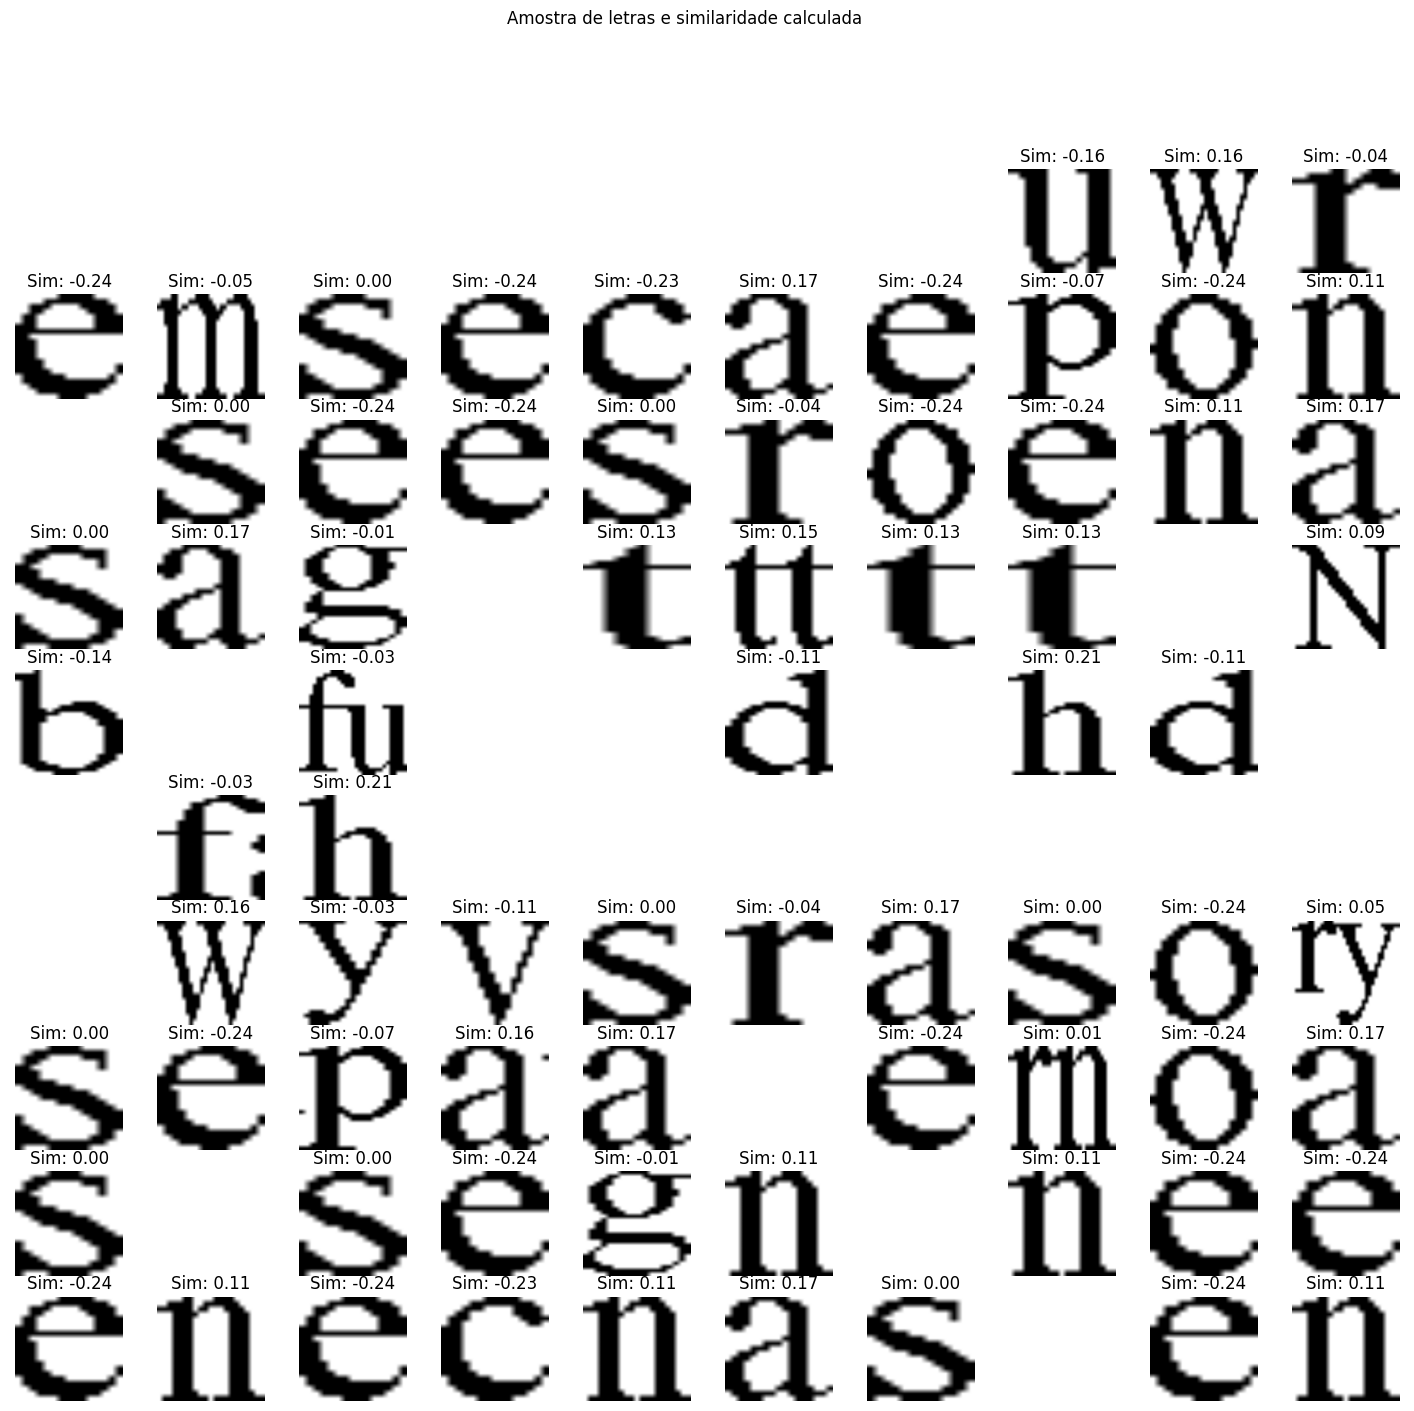

In [ ]:
fig, ax = plt.subplots(10, 10, figsize=(18, 16))
ax = ax.flatten()
for i, contorno in enumerate(contornos):
    x, y, w, h = cv2.boundingRect(contorno)

    letra = img_bin[y:(y + h), x:(x + w)]  # recorta a letra da iamgem
    letra_resized = cv2.resize(
        letra,
        (image_template.shape[1], image_template.shape[0])
    )  # redimensiona para o tamanho do template

    letra_norm = 1 - letra_resized / 255.0 # re normalizando para retornar com o fundo branco e letra preta

    # Outro formato de uso usando a biblioteca OpenCV ###############################################################
    # res = cv2.matchTemplate(
    #     letra_norm.astype(np.float32),
    #     image_template.astype(np.float32),
    #     cv2.TM_CCOEFF_NORMED
    # )[0][0]  # calculo de similaridade explicitado
    #################################################################################################################
    res = tm_ccoef_normed(letra_norm, image_template)  # calculo de similaridade
    simililarity = res[0][0]

    contents["contornos"].append(contorno)
    contents["letra"].append(letra)
    contents["letra_norm"].append(letra_norm)
    contents["similarity"].append(simililarity)

    if w < 10 or h < 10:  # contornos muito pequenos não serão mostrados
        if i < (10 * 10):
            ax[i].axis("off")
        contents["check_is_valid"].append(False)
        continue
    contents["check_is_valid"].append(True)

    if i < (10 * 10):
        ax[i].imshow(letra_norm, cmap='gray')
        ax[i].axis("off")
        ax[i].set_title(f"Sim: {simililarity:.2f}")
fig.savefig(path_assets / "atv02-q08-i02_k04.png", dpi=400, bbox_inches='tight')
fig.suptitle("Amostra de letras e similaridade calculada")

### 2.5) Threshold para similaridade

Considerando o  calculo utilizado para a similaridade, será utilizado um *threshold* de $0.5$ para a métrica utilizada, aonde temos:

$$
\text{Resultado} = 
\begin{cases} 
\text{Letra 'A' encontrada}, & \text{se } thres \geq 0.5 \\
\text{Letra 'A' não encontrada}, & \text{se } thres < 0.5
\end{cases}
$$

### 2.6) Conclusão

O algoritmo desenvolvido não detectou a presença da letra **A** maiuscula ao longo da imagem.

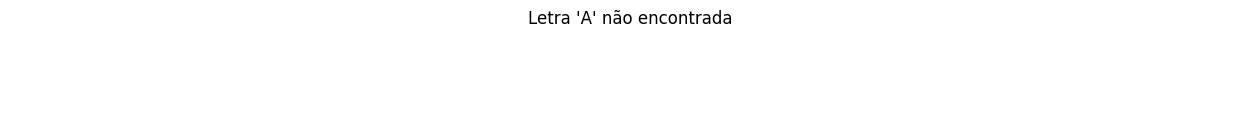

In [157]:
ks = np.where((np.array(contents["similarity"]) >= 0.5) & (np.array(contents["check_is_valid"]) == True))[0]
n = math.ceil(math.sqrt(len(ks)))

if n != 0:
    fig, axes = plt.subplots(
        n,
        n,
        figsize=(n * 3, n * 3)
    )


    for value, _axes in zip(ks, axes.flatten()):
        print("test")
        _axes.imshow(contents["letra_norm"][value], cmap="gray")
        _axes.set_title(f"Contorno: {value}")

    for _axes in axes.flatten():
        _axes.axis('off')

    text = f"Letra 'A' {'encontrada' if len(ks) >= 1 else 'inexistente'}"
    text += f" | Total: {len(ks)}"
    fig.suptitle(text, fontsize=16, weight='bold')
    fig.savefig(path_assets / "atv02-q08-i02_k05.png", dpi=400, bbox_inches='tight')
    plt.show()
else:
    fig, axes = plt.subplots(
        1,
        1,
        figsize=(16, 1)
    )
    axes.set_title("Letra 'A' não encontrada")
    axes.axis('off')
    fig.savefig(path_assets / "atv02-q08-i02_k05.png", dpi=400, bbox_inches='tight')